# Get Long and Lat for all countries in the DB

In [31]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import pandas as pd

excel_db = pd.read_excel("../data/destinations_infos.xlsx")

geolocator = Nominatim(user_agent="myapplication")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

results_dict = {}

matched_counties, unmatched_counties = 0, 0
successful_calls, failed_calls = 0, 0

for _, row in excel_db.iterrows():
    query = f"{row['destination']}, {row['country']}"
    print(f"Query: {query}")
    
    location = geocode(query, language="en")

    if location:
        successful_calls += 1

        lat = location.latitude
        lon = location.longitude
        
        display_name = location.raw.get("display_name", "")
        country_match = row["country"].lower() in display_name.lower()

        results_dict[row['destination']] = {
            "latitude": lat,
            "longitude": lon,
            "country_match": country_match
        }
        print(f"Data successfully retrieved: Lat:{lat}, Long:{lon}, Country Match:{country_match}")

        if country_match:
            matched_counties += 1
        else:
            unmatched_counties += 1

    else:
        print("Location not found for query")
        failed_calls += 1
        results_dict[query] = {
            "latitude": None,
            "longitude": None,
            "country_match": False
        }

print(f"Successful calls: {successful_calls}")
print(f"Failed calls: {failed_calls}")

Query: Bali, Indonesia
Data successfully retrieved: Lat:-8.2271303, Long:115.1919203, Country Match:True
Query: Paris, France
Data successfully retrieved: Lat:48.8534951, Long:2.3483915, Country Match:True
Query: Tokyo, Japan
Data successfully retrieved: Lat:35.6768601, Long:139.7638947, Country Match:True
Query: New York, United States
Data successfully retrieved: Lat:40.7127281, Long:-74.0060152, Country Match:True
Query: Cape Town, South Africa
Data successfully retrieved: Lat:-33.9288301, Long:18.4172197, Country Match:True
Query: Sydney, Australia
Data successfully retrieved: Lat:-33.8698439, Long:151.2082848, Country Match:True
Query: Rome, Italy
Data successfully retrieved: Lat:41.8933203, Long:12.4829321, Country Match:True
Query: Rio de Janeiro, Brazil
Data successfully retrieved: Lat:-22.9110137, Long:-43.2093727, Country Match:True
Query: London, United Kingdom
Data successfully retrieved: Lat:51.5074456, Long:-0.1277653, Country Match:True
Query: Santorini, Greece
Data succ

# Use Openmeteo API to get the weather data

In [42]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)
url = "https://api.open-meteo.com/v1/forecast"

successful_calls, failed_calls = 0, 0

for location_name, data in results_dict.items():
    
    if data["latitude"] is None or data["longitude"] is None:
        continue

    params = {
        "latitude": data["latitude"],
        "longitude": data["longitude"],
        "hourly": ["temperature_2m", "wind_speed_10m", "precipitation_probability", "precipitation"],
        "current": ["temperature_2m", "wind_speed_10m", "precipitation"],
        "past_days": 3,
	    "forecast_days": 3,
    }

    try:
        responses = openmeteo.weather_api(url, params=params)
        response = responses[0]

        # Get Current Weather
        current = response.Current()
        current_weather_dict = {
            "temperature": current.Variables(0).Value(),
            "wind_speed": current.Variables(1).Value(),
            "current_precipitation" : current.Variables(2).Value()
        }
        results_dict[location_name]["current_weather"] = current_weather_dict

        # Get Past and Forecast Data
        hourly = response.Hourly()
        hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
        hourly_wind_speed_10m = hourly.Variables(1).ValuesAsNumpy()
        hourly_precipitation_probability = hourly.Variables(2).ValuesAsNumpy()
        hourly_precipitation = hourly.Variables(3).ValuesAsNumpy()

        hourly_data = {"date": pd.date_range(
            start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
            end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
            freq = pd.Timedelta(seconds = hourly.Interval()),
            inclusive = "left"
        )}

        hourly_data["temperature_2m"] = hourly_temperature_2m
        hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
        hourly_data["precipitation_probability"] = hourly_precipitation_probability
        hourly_data["precipitation"] = hourly_precipitation
        hourly_dataframe = pd.DataFrame(data = hourly_data)
        results_dict[location_name]["all_weather"] = hourly_dataframe


        print(f"Data successfully retrieved for {location_name}")

        successful_calls += 1
    
    except Exception as e:
        failed_calls += 1
        print(f"Failed to get data for {location_name}: {e}")

print(f"Successful calls: {successful_calls}")
print(f"Failed calls: {failed_calls}")

Data successfully retrieved for Bali
Data successfully retrieved for Paris
Data successfully retrieved for Tokyo
Data successfully retrieved for New York
Data successfully retrieved for Cape Town
Data successfully retrieved for Sydney
Data successfully retrieved for Rome
Data successfully retrieved for Rio de Janeiro
Data successfully retrieved for London
Data successfully retrieved for Santorini
Data successfully retrieved for Vancouver
Data successfully retrieved for Bangkok
Data successfully retrieved for Istanbul
Data successfully retrieved for Cairo
Data successfully retrieved for Barcelona
Data successfully retrieved for Reykjavik
Data successfully retrieved for Buenos Aires
Data successfully retrieved for Kyoto
Data successfully retrieved for Honolulu
Successful calls: 19
Failed calls: 0


# Example of output : Tokyo Japan

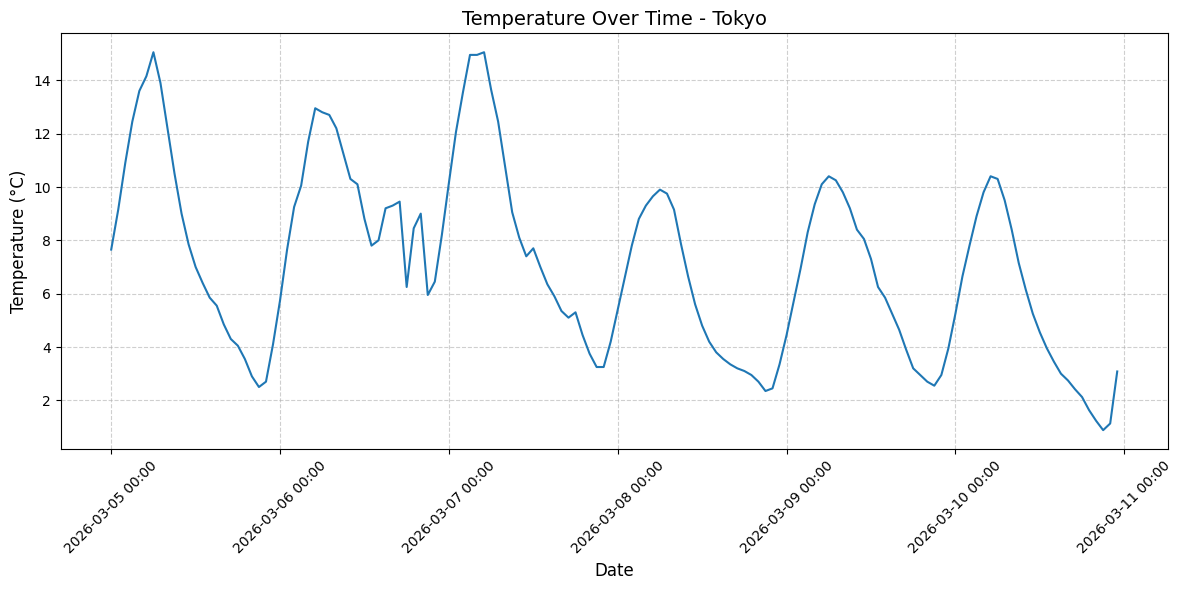

In [56]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

results_df = results_dict["Tokyo"]["all_weather"]

plt.figure(figsize=(12, 6))

plt.plot(results_df['date'], results_df['temperature_2m'])

plt.title("Temperature Over Time - Tokyo", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()